# Part 2(a)

In [1]:
# 1.Select only relevant columns and remove NA
# 2.Adjust delays, categorize flight times and extract days of the week
# 3.Calculate average delays by time of day and day of the week
# 4.Plot bar charts to show the best times and best days to fly with the lowest delays

In [3]:
# Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Load data and import it into data frame
airports_df = pd.read_csv('airports.csv')
carriers_df = pd.read_csv('carriers.csv')
planes_df = pd.read_csv('plane-data.csv')
ontime_df = pd.concat(
            [pd.read_csv(f"{year}.csv/{year}.csv") for year in range(2004, 2009)]
            ,ignore_index=True
            )

## Data Cleaning and Adjustment

In [8]:
# 1.Remove NA values for accurate analysis
# 2.Consider minor delays (<15 mins) as no delay
# 3.Create total delay, time category and change date format
# 4.Extract day of week

In [10]:
# Keep only essential columns and remove incomplete records
part_a_df = ontime_df[['Year', 'Month', 'DayofMonth', 'DepTime', 'DepDelay', 'ArrDelay']].dropna()

In [12]:
part_a_df.loc[part_a_df['DepDelay'] < 15, 'DepDelay'] = 0  # Set values <15 to 15
part_a_df.loc[part_a_df['ArrDelay'] < 15, 'ArrDelay'] = 0 
part_a_df['TotalDelay'] = part_a_df['DepDelay'] + part_a_df['ArrDelay'] # Calculate total delay 

In [14]:
# Extract hour from departure time
part_a_df['Hour'] = (part_a_df['DepTime'] // 100) 

# Categorize time 
part_a_df['TimeCategory'] = pd.cut(
                            part_a_df['Hour'],
                            bins=[0, 5, 12, 19, 24],  
                            labels=["Early Morning", "Morning", "Afternoon", "Night"]
                            )

In [16]:
# Create date in dd-mm-yy format 
part_a_df['Date'] = pd.to_datetime(
    part_a_df['Year'].astype(str) + '-' +
    part_a_df['Month'].astype(str) + '-' + 
    part_a_df['DayofMonth'].astype(str),
    format = '%Y-%m-%d'
)

# Extract day of week
part_a_df['DayOfWeek'] = part_a_df['Date'].dt.day_name()

In [18]:
print(part_a_df[['Date', 'DayOfWeek']].head())

        Date  DayOfWeek
0 2004-01-12     Monday
1 2004-01-13    Tuesday
2 2004-01-14  Wednesday
3 2004-01-15   Thursday
4 2004-01-16     Friday


## Analyze Best Flight Times

In [21]:
best_flight_times = (
    part_a_df.groupby('TimeCategory',observed=True)['TotalDelay']
    .mean()
    .reset_index()
    .sort_values(by = 'TotalDelay')
    .round(2)  # Round TotalDelay to 2 decimal places
)
# Best flight times table
best_flight_times = best_flight_times.reset_index(drop=True)
print(best_flight_times)


    TimeCategory  TotalDelay
0        Morning       11.18
1  Early Morning       15.08
2      Afternoon       26.61
3          Night       54.54


## Analyze Best Flight Days

In [24]:
best_flight_days = (
    part_a_df.groupby('DayOfWeek',observed = True)['TotalDelay']
    .mean()
    .reset_index()
    .sort_values(by = 'TotalDelay')
    .round(2) 
)
# Best flight days table
best_flight_days = best_flight_days.reset_index(drop = True)
print(best_flight_days)


   DayOfWeek  TotalDelay
0   Saturday       18.12
1    Tuesday       20.10
2  Wednesday       22.00
3     Sunday       22.85
4     Monday       23.74
5   Thursday       25.41
6     Friday       26.46


## Visualize optimal flight times with the lowest delays

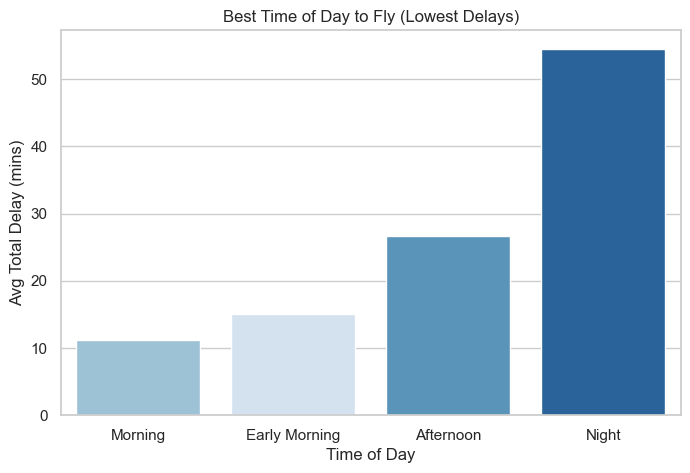

In [27]:
sns.set(style = "whitegrid")
plt.figure(figsize = (8,5))
sns.barplot(data = best_flight_times, x = "TimeCategory", y = "TotalDelay",
            hue = "TimeCategory",dodge = False,
            order = best_flight_times['TimeCategory'], 
            palette = "Blues")
plt.title("Best Time of Day to Fly (Lowest Delays)")
plt.xlabel("Time of Day")
plt.ylabel("Avg Total Delay (mins)")
plt.show()

## Visualize optimal flight days with the lowest delays

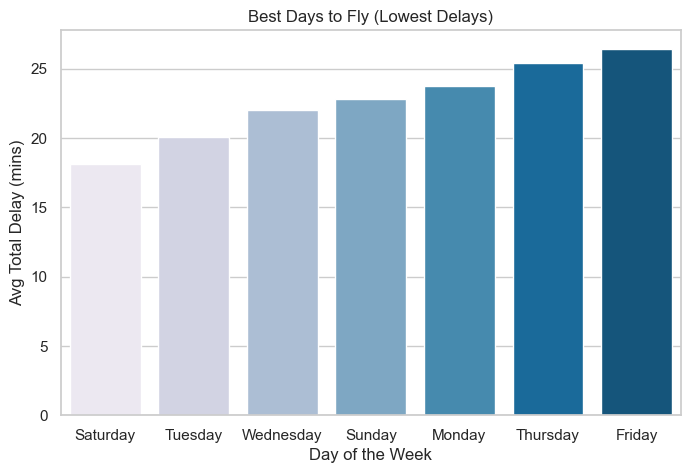

In [30]:
blue_palette = sns.light_palette("mediumblue", as_cmap = True)
plt.figure(figsize = (8,5))
sns.barplot(data = best_flight_days, x = "DayOfWeek", y = "TotalDelay",
            hue = "DayOfWeek", dodge = False,
            order = best_flight_days['DayOfWeek'],
            palette = "PuBu")
plt.title("Best Days to Fly (Lowest Delays)")
plt.xlabel("Day of the Week")
plt.ylabel("Avg Total Delay (mins)")
plt.show()

# Part 2(b)

In [33]:
# 1.Filter out cancelled and diverted flights to focus on delays
# 2.Calculate plane age by comparing flight year to manufacturing year
# 3.Adjust delays by considering minor delays (<15 mins) as zero
# 4.Aggregate data to compute average delays per plane age
# 5.Visualize results with a line plot (age vs. average delay)
# 6.Analyze trend to determine if older planes experience more delays

In [35]:
# Load libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
# Load data and import it into data frame
airports_df = pd.read_csv('airports.csv')
carriers_df = pd.read_csv('carriers.csv')
planes_df = pd.read_csv('plane-data.csv')
ontime_df = pd.concat(
            [pd.read_csv(f"{year}.csv/{year}.csv") for year in range(2004, 2009)]
            ,ignore_index=True
            )

## Remove cancelled and diverted flights, select relevant attributes

In [40]:
# Convert Cancelled == 1 and Diverted == 1 to NA, then drop NA rows
ontime_df["Cancelled"] = ontime_df["Cancelled"].replace(1, pd.NA)
ontime_df["Diverted"] = ontime_df["Diverted"].replace(1, pd.NA)
ontime_df = ontime_df.dropna(subset=["Cancelled", "Diverted"])

# Select relevant attributes
part_b_df = ontime_df[["Year", "TailNum", "ArrDelay", "DepDelay"]]

## Merge data and calculate age 

In [43]:
part_b_merged_df = part_b_df.merge(planes_df[["tailnum", "year"]], left_on="TailNum", right_on="tailnum", how="left")

part_b_merged_df["Year"] = pd.to_numeric(part_b_merged_df["Year"], errors="coerce") # Convert columns to numeric
part_b_merged_df["year"] = pd.to_numeric(part_b_merged_df["year"], errors="coerce")

part_b_merged_df["Age"] = part_b_merged_df["Year"] - part_b_merged_df["year"]

## Adjust Delays, compute total delay and filter valid values

In [46]:
part_b_merged_df["DepDelay"] = part_b_merged_df["DepDelay"].apply(lambda x: 0 if x < 15 else x) # Replace DepDelay and ArrDelay < 15 with 0
part_b_merged_df["ArrDelay"] = part_b_merged_df["ArrDelay"].apply(lambda x: 0 if x < 15 else x)

part_b_merged_df["totdelay"] = part_b_merged_df["ArrDelay"] + part_b_merged_df["DepDelay"] # Compute total delay

# Filter valid values and drop NA
part_b_merged_df = part_b_merged_df[(part_b_merged_df["Age"] >= 0) & (part_b_merged_df["Age"] <= 100)].dropna(subset=["Age"]) 

## Aggregate: Compute average total delay by aircraft age

In [49]:
part_b_graph_df = part_b_merged_df.groupby("Age")["totdelay"].mean().reset_index()
part_b_graph_df.rename(columns = {"totdelay": "avg_totdelay"}, inplace = True)



## Plot the relationship between plane age and average delays

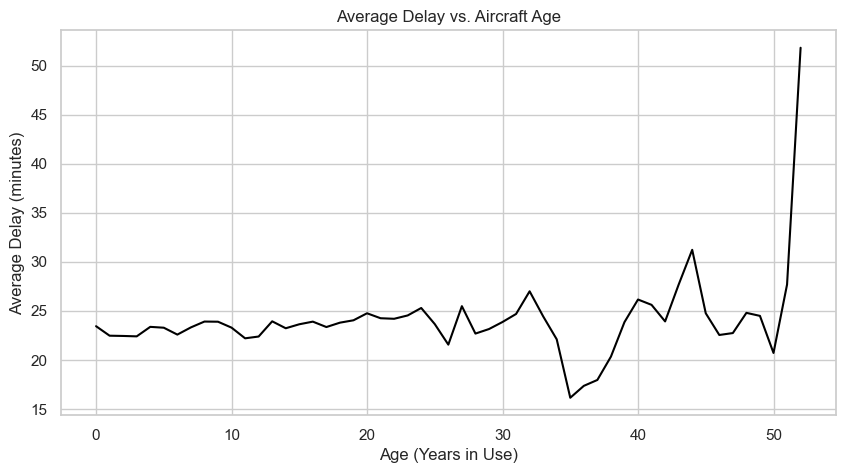

In [52]:
plt.figure(figsize = (10, 5))
sns.lineplot(data = part_b_graph_df, x = "Age", y = "avg_totdelay", color = "black")

plt.title("Average Delay vs. Aircraft Age")
plt.xlabel("Age (Years in Use)")
plt.ylabel("Average Delay (minutes)")
plt.grid(True)

plt.show()